# Importación de las librerías necesarias para la ejecución #

In [1]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Lectura de los datos de los partidos ya formateados en .csv

In [2]:
# Lista para almacenar los DataFrames leídos
dataframes = []

# Leer los archivos CSV que contienen los DataFrames
archivos = ['SP1-1011.csv','SP1-1112.csv','SP1-1213.csv','SP1-1314.csv',
            'SP1-1415.csv','SP1-1516.csv', 'SP1-1617.csv', 'SP1-1718.csv',
            'SP1-1819.csv', 'SP1-1920.csv', 'SP1-2021.csv', 'SP1-2122.csv', 
            'SP1-2223.csv', 'SP1-2324.csv']

#archivos = ['SP1-1314.csv']

archivos_segunda = ['SP2-1011.csv','SP2-1112.csv',
            'SP2-1213.csv','SP2-1314.csv','SP2-1415.csv','SP2-1516.csv', 
            'SP2-1617.csv', 'SP2-1718.csv','SP2-1819.csv', 'SP2-1920.csv', 
            'SP2-2021.csv', 'SP2-2122.csv', 'SP2-2223.csv', 'SP2-2324.csv']

#archivos += archivos_segunda

for archivo in archivos:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("Datos_Formateados/"+archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

(5199, 17)

In [3]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HY,AY,HR,AR,FTR
0,SP1,28/08/10,Hercules,Ath Bilbao,0,1,0,0,9,14,3,5,2,4,1,0,A
1,SP1,28/08/10,Levante,Sevilla,1,4,1,2,7,14,4,8,4,4,0,0,A
2,SP1,28/08/10,Malaga,Valencia,1,3,1,1,19,21,5,8,2,5,0,0,A
3,SP1,29/08/10,Espanol,Getafe,3,1,1,0,17,13,8,1,3,4,0,0,H
4,SP1,29/08/10,La Coruna,Zaragoza,0,0,0,0,8,8,2,3,0,1,0,0,D


In [4]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Hercules',
 'Ath Bilbao',
 'Levante',
 'Sevilla',
 'Malaga',
 'Valencia',
 'Espanol',
 'Getafe',
 'La Coruna',
 'Zaragoza',
 'Mallorca',
 'Real Madrid',
 'Osasuna',
 'Almeria',
 'Santander',
 'Barcelona',
 'Sociedad',
 'Villarreal',
 'Ath Madrid',
 'Sp Gijon',
 'Granada',
 'Betis',
 'Vallecano',
 'Celta',
 'Valladolid',
 'Elche',
 'Eibar',
 'Cordoba',
 'Las Palmas',
 'Alaves',
 'Leganes',
 'Girona',
 'Huesca',
 'Cadiz']

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [5]:
condicion = (datos_partidos['FTR'] != 'A') & (datos_partidos['FTR'] != 'H') & (datos_partidos['FTR'] != 'D')
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

### Obtención del gol average medio de cada partido

In [6]:
dict_ultimo_gol_average_equipo = {}

def get_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
    return lista_goles_por_partido

def get_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
    return lista_goles_por_partido

def get_media_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    # añadir que si ve que el año de la temporada es distinto a uno previo goles acumulados = 0 para que cada temporada se reinicie
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido

def get_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_marcados_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_gol_average_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_goles_marcados_por_partido):
        lista_media_gol_average_por_partido.append((valor - lista_goles_encajados_por_partido[idx] + valor_acumulado) / (idx+1))
        valor_acumulado += (valor - lista_goles_encajados_por_partido[idx])
    return lista_media_gol_average_por_partido

lista_listas_gol_average_medio_cada_equipo = []
equipos = get_equipos(dataframe=datos_partidos)
for equipo in equipos:
    lista_gol_average_medio_un_equipo = get_media_gol_average_por_partido(dataframe=datos_partidos, equipo=equipo)
    lista_gol_average_medio_un_equipo.insert(0,0)
    dict_ultimo_gol_average_equipo[equipo] = lista_gol_average_medio_un_equipo[-1]
    lista_gol_average_medio_un_equipo.pop()
    lista_listas_gol_average_medio_cada_equipo.append(lista_gol_average_medio_un_equipo)
len(lista_listas_gol_average_medio_cada_equipo)

34

### Obtención de la diferencia de gol average medio respecto al partido anterior

In [7]:
dict_ultimas_diferencias_cada_equipo = {}

def get_diferencia_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_gol_average_por_partido = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_gol_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

lista_listas_diferencias_gol_average_medio_cada_equipo = []
for equipo in equipos:
    lista_diferencias_gol_average_medio_un_equipo = get_diferencia_media_gol_average_por_partido(dataframe=datos_partidos, equipo=equipo)
    lista_diferencias_gol_average_medio_un_equipo.insert(0,0)
    dict_ultimas_diferencias_cada_equipo[equipo] = lista_diferencias_gol_average_medio_un_equipo[-1]
    lista_diferencias_gol_average_medio_un_equipo.pop()
    lista_listas_diferencias_gol_average_medio_cada_equipo.append(lista_diferencias_gol_average_medio_un_equipo)
len(lista_listas_diferencias_gol_average_medio_cada_equipo)

34

### Obtención media tarjetas rojas por partido

In [8]:
dict_ultimas_rojas_cada_equipo = {}

def get_tarjetas_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_rojas_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_rojas_por_partido.append(partido['HR'])
        if partido['AwayTeam'] == equipo:
            lista_rojas_por_partido.append(partido['AR'])
    return lista_rojas_por_partido

def get_media_rojas_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_tarjetas_rojas_por_partido = get_tarjetas_rojas_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_tarjetas_rojas_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_tarjetas_rojas_por_partido):
        lista_media_tarjetas_rojas_por_partido.append((valor + valor_acumulado) / (idx+1))
        valor_acumulado += valor
    return lista_media_tarjetas_rojas_por_partido

lista_listas_rojas_por_partido_cada_equipo = []
for equipo in equipos:
    lista_rojas_por_partido_un_equipo = get_media_rojas_por_partido(dataframe=datos_partidos, equipo=equipo)
    lista_rojas_por_partido_un_equipo.insert(0,0)
    dict_ultimas_rojas_cada_equipo[equipo] = lista_rojas_por_partido_un_equipo[-1]
    lista_rojas_por_partido_un_equipo.pop()
    lista_listas_rojas_por_partido_cada_equipo.append(lista_rojas_por_partido_un_equipo)
len(lista_listas_rojas_por_partido_cada_equipo)

34

### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [9]:
lb_make = LabelEncoder()
datos_partidos['target FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HomeTeam'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['AwayTeam'])

In [10]:
datos_partidos['FTR'].value_counts()

FTR
H    2425
A    1468
D    1306
Name: count, dtype: int64

In [11]:
datos_partidos['target FTR'].value_counts()

target FTR
2    2425
0    1468
1    1306
Name: count, dtype: int64

### Inserción de los datos de gol average, diferencia y rojas en las filas de cada partido

In [12]:
for idx_equipos,equipo in enumerate(equipos):
    partidos_del_equipo = datos_partidos.loc[(datos_partidos['HomeTeam'] == equipo) | (datos_partidos['AwayTeam'] == equipo)]
    idx_partidos = 0
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            datos_partidos.at[idx,'Gol_Average_Home'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
            datos_partidos.at[idx,'Dif_Home'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
            datos_partidos.at[idx,'Rojas_Home'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
        if partido['AwayTeam'] == equipo:
            datos_partidos.at[idx,'Gol_Average_Away'] = lista_listas_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
            datos_partidos.at[idx,'Dif_Away'] = lista_listas_diferencias_gol_average_medio_cada_equipo[idx_equipos][idx_partidos]
            datos_partidos.at[idx,'Rojas_Away'] = lista_listas_rojas_por_partido_cada_equipo[idx_equipos][idx_partidos]
        idx_partidos += 1
            
datos_partidos.to_csv("intermedio.csv")

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [13]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
gol_average_home = datos_partidos['Gol_Average_Home']
gol_average_away = datos_partidos['Gol_Average_Away']
gol_averages = datos_partidos[['Gol_Average_Home','Gol_Average_Away']]
diferencia_home = datos_partidos['Dif_Home']
diferencia_away = datos_partidos['Dif_Away']
diferencias = datos_partidos[['Dif_Home','Dif_Away']]
rojas_home = datos_partidos['Rojas_Home']
rojas_away = datos_partidos['Rojas_Away']
rojas = datos_partidos[['Rojas_Home','Rojas_Away']]
columnas_features = ['Gol_Average_Home','Gol_Average_Away','Dif_Home','Dif_Away','Rojas_Home','Rojas_Away']
features = datos_partidos[columnas_features]
target = datos_partidos['target FTR']

### Separación del objetivo de predicción en clases binarias

In [14]:
target = to_categorical(target)
target.shape

(5199, 3)

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

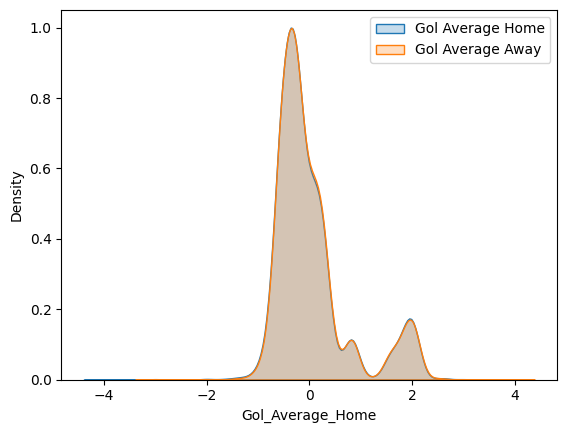

In [15]:
columnas = ['Gol Average Home','Gol Average Away']
for i, col in enumerate(gol_averages.columns):
    sns.kdeplot(gol_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

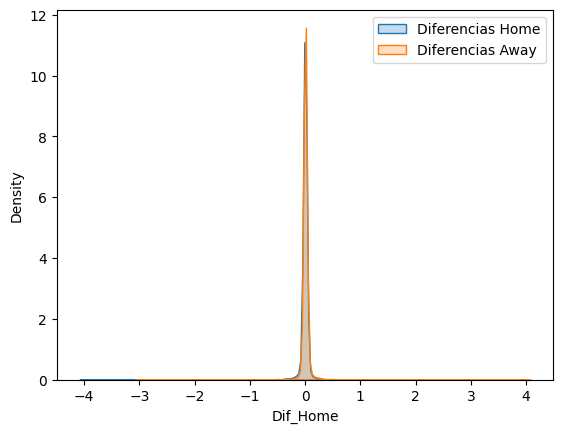

In [16]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

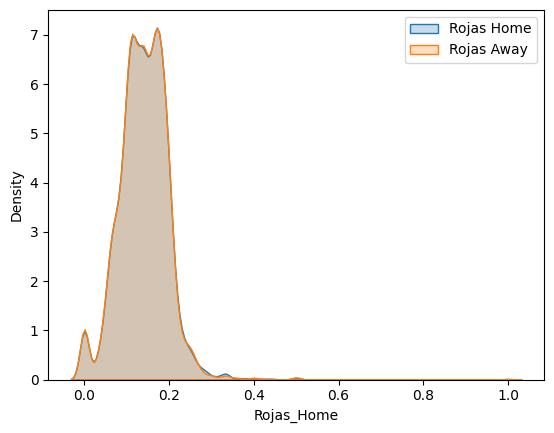

In [17]:
columnas = ['Rojas Home','Rojas Away']
for i, col in enumerate(rojas.columns):
    sns.kdeplot(rojas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [18]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Gol_Average_Home,Gol_Average_Away,Dif_Home,Dif_Away,Rojas_Home,Rojas_Away
0,0.571429,0.428571,0.571429,0.428571,0.0,0.0
1,0.571429,0.428571,0.571429,0.428571,0.0,0.0
2,0.571429,0.428571,0.571429,0.428571,0.0,0.0
3,0.571429,0.428571,0.571429,0.428571,0.0,0.0
4,0.571429,0.428571,0.571429,0.428571,0.0,0.0


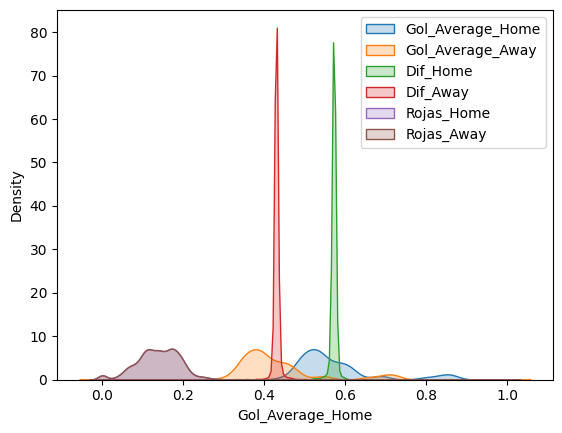

In [19]:
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [20]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(5199, 68)

In [21]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.column_stack((equipos_encoded,features_normalized_dataframe))

In [22]:
predictores.shape

(5199, 74)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [23]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.3, random_state=4)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (3639, 74) (3639, 3)
Test set: (1560, 74) (1560, 3)


### Definición y construcción del modelo

In [24]:
def get_modelo_regresion(features: pd.DataFrame) -> Sequential:
    numero_predictores = features.shape[1]
    #Crear el modelo
    model = Sequential()
    model.add(Dense(80, activation='relu', input_shape=(numero_predictores,)))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(15, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    #Compilar modelo
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

modelo = get_modelo_regresion(features=predictores)

### Entrenamiento del modelo

In [25]:
iteraciones=4
historial_entrenamiento=modelo.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

Epoch 1/200
114/114 [==============================] - 7s 19ms/step - loss: 1.0470 - accuracy: 0.4790 - val_loss: 1.0168 - val_accuracy: 0.4994
Epoch 2/200
114/114 [==============================] - 1s 9ms/step - loss: 0.9850 - accuracy: 0.5257 - val_loss: 0.9810 - val_accuracy: 0.5212
Epoch 3/200
114/114 [==============================] - 1s 10ms/step - loss: 0.9589 - accuracy: 0.5383 - val_loss: 0.9792 - val_accuracy: 0.5058
Epoch 4/200
114/114 [==============================] - 1s 10ms/step - loss: 0.9520 - accuracy: 0.5411 - val_loss: 0.9851 - val_accuracy: 0.5064
Epoch 5/200
114/114 [==============================] - 1s 10ms/step - loss: 0.9423 - accuracy: 0.5491 - val_loss: 0.9838 - val_accuracy: 0.5199
Epoch 6/200
114/114 [==============================] - 1s 10ms/step - loss: 0.9365 - accuracy: 0.5545 - val_loss: 0.9878 - val_accuracy: 0.5192
Epoch 7/200
114/114 [==============================] - 1s 10ms/step - loss: 0.9283 - accuracy: 0.5614 - val_loss: 0.9897 - val_accuracy: 

KeyboardInterrupt: 

## -Evaluación del modelo

### Evolución del modelo

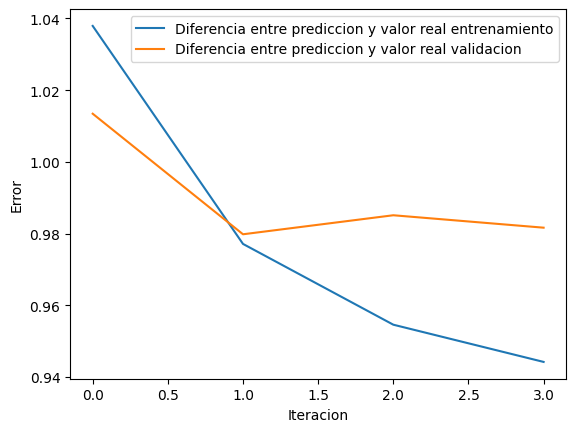

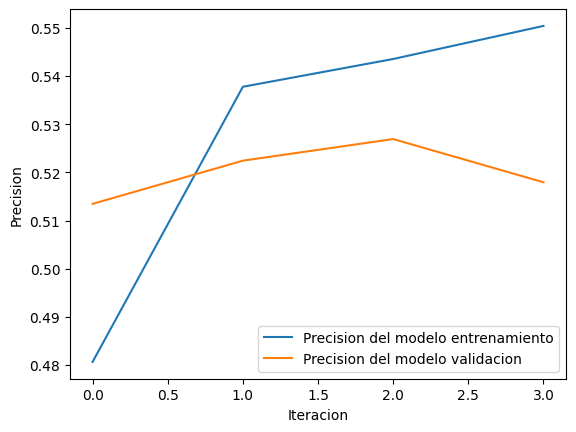

In [87]:
def plot_entrenamiento(historial):
    hist = pd.DataFrame(historial.history)
    hist['iteracion'] = historial.epoch

    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Error')
    plt.plot(hist['iteracion'], hist['loss'],label='Diferencia entre prediccion y valor real entrenamiento')
    plt.plot(hist['iteracion'], hist['val_loss'],label = 'Diferencia entre prediccion y valor real validacion')
    plt.legend()
    
    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Precision')
    plt.plot(hist['iteracion'], hist['accuracy'],label='Precision del modelo entrenamiento')
    plt.plot(hist['iteracion'], hist['val_accuracy'],label = 'Precision del modelo validacion')
    plt.legend()
    
    plt.show()
    
plot_entrenamiento(historial = historial_entrenamiento)

### Evaluación

In [88]:
test1 = modelo.evaluate(features_test, target_test, verbose=0)
print('Test loss:', round(test1[0],3)) 
print('Test accuracy:', round(test1[1],3))

Test loss: 0.982
Test accuracy: 0.518


## - Predicción real de un partido

In [91]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Las Palmas'
AT='Getafe'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

0.11428571428571428
0.18672199170124482


### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [92]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 68)

In [94]:
features = pd.DataFrame(data=(gol_average_home,gol_average_away,dif_home,dif_away,rojas_home,rojas_away), columns=columnas_features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

ValueError: Shape of passed values is (6, 1), indices imply (6, 6)

In [391]:
predictores = np.append(equipos_encoded, [[racha_local, racha_visitante]], axis=1)
predictores.shape

(1, 70)

### Predicción del valor objetivo

In [392]:
pred1 = modelo.predict(predictores)
pred1

1/1 [==============================] - 0s 70ms/step


array([[0.2757083 , 0.27368477, 0.450607  ]], dtype=float32)

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [393]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [394]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [395]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

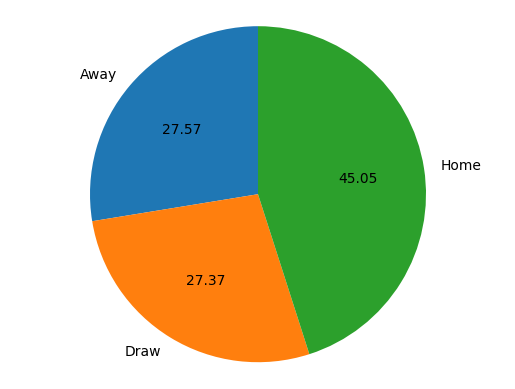

In [396]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()